## Case study: MEA CO2 Capture

## Step 1: Exploratory data analysis


In [1]:
# Why EDA: To check whether data is sensible, quality, correlation of variables

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

In [3]:
df=pd.read_excel("/Users/adithya/Desktop/Materials/Jupyter/Dataset/CO2_Capture.xlsx",skiprows=1)

print(df.columns)
print(df.dtypes)
print(df.shape)
print(df.describe().round(2))
print(df.isnull().sum())

df

Index(['run_id', 'amine_conc', 'L_G_ratio', 'absorber_T', 'stripper_P',
       'flue_CO2', 'capture_rate', 'Q_reboiler', 'Q_condenser', 'solvent_loss',
       'elec_compressor', 'elec_pumps', 'cooling_water', 'rich_loading',
       'lean_loading', 'delta_loading'],
      dtype='object')
run_id               int64
amine_conc         float64
L_G_ratio          float64
absorber_T         float64
stripper_P         float64
flue_CO2           float64
capture_rate       float64
Q_reboiler         float64
Q_condenser        float64
solvent_loss       float64
elec_compressor    float64
elec_pumps         float64
cooling_water      float64
rich_loading       float64
lean_loading       float64
delta_loading      float64
dtype: object
(300, 16)
       run_id  amine_conc  L_G_ratio  absorber_T  stripper_P  flue_CO2  \
count  300.00      300.00     300.00      300.00      300.00    300.00   
mean   150.50       30.00       3.25       47.50        1.85     10.00   
std     86.75        5.78       1.

,run_id,amine_conc,L_G_ratio,absorber_T,stripper_P,flue_CO2,capture_rate,Q_reboiler,Q_condenser,solvent_loss,elec_compressor,elec_pumps,cooling_water,rich_loading,lean_loading,delta_loading
0,1,25.3,4.68,38.9,1.76,8.0,76.5,3.720,1.447,1.60,91.6,37.0,122.2,0.479,0.279,0.200
1,2,36.0,5.38,49.6,1.60,7.7,77.0,4.835,1.748,1.93,87.4,37.8,135.5,0.498,0.319,0.179
2,3,27.8,4.81,47.5,1.76,12.7,83.9,4.393,1.650,1.79,91.6,34.4,122.2,0.468,0.272,0.196
3,4,30.5,4.05,54.7,1.66,12.4,81.6,5.517,1.923,2.12,92.1,32.3,128.6,0.499,0.310,0.189
4,5,25.9,4.17,44.3,1.51,9.5,75.0,3.894,1.441,1.71,88.3,32.5,105.7,0.452,0.302,0.150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,22.3,2.33,41.2,1.38,12.7,72.8,3.379,1.158,1.61,94.6,22.1,90.6,0.418,0.267,0.151
296,297,39.6,2.11,57.9,1.87,9.2,70.0,6.043,1.854,2.21,100.7,21.9,129.2,0.476,0.306,0.170
297,298,36.3,4.83,58.1,1.41,12.5,82.5,6.476,2.205,2.22,91.8,34.5,150.0,0.492,0.291,0.201
298,299,34.4,1.87,48.1,1.42,11.7,73.0,4.024,1.325,1.93,91.2,23.5,90.1,0.475,0.308,0.167


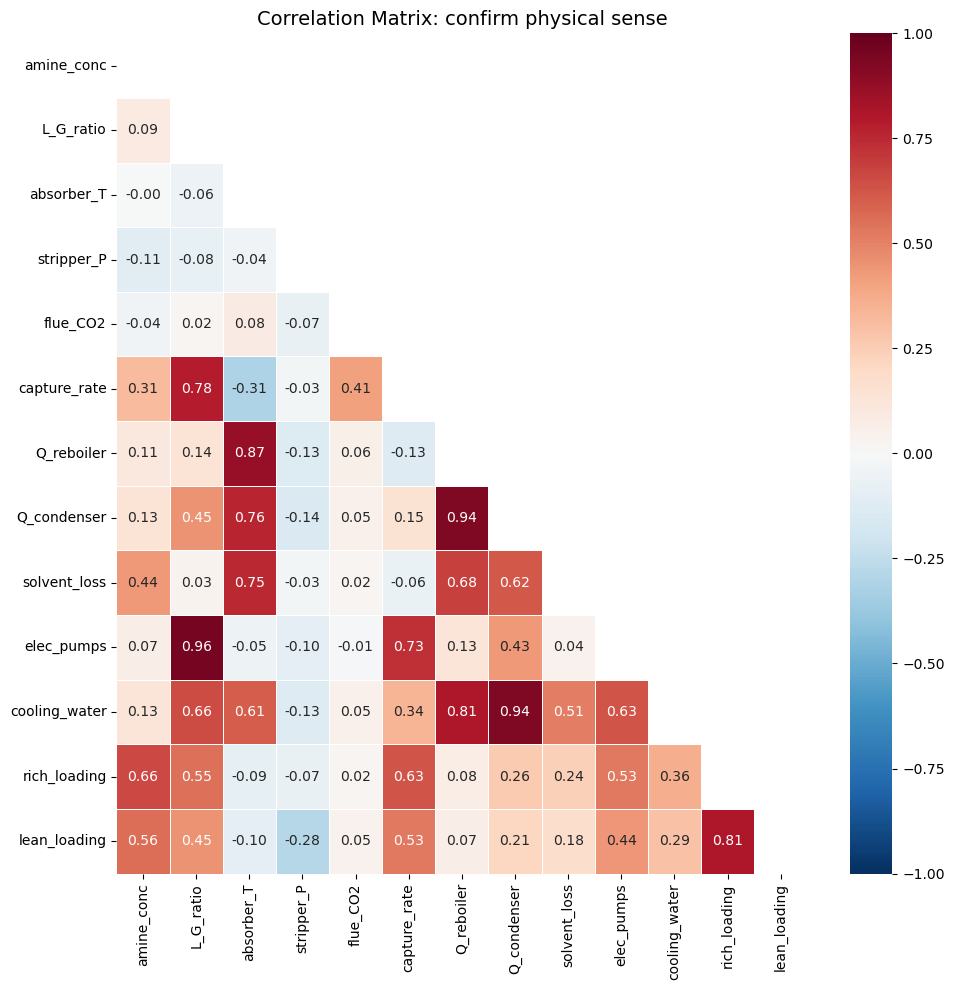

In [4]:
plt.figure(figsize=(10,10))

cols=['amine_conc', 'L_G_ratio', 'absorber_T', 'stripper_P',
       'flue_CO2', 'capture_rate', 'Q_reboiler', 'Q_condenser', 'solvent_loss',
       'elec_pumps', 'cooling_water', 'rich_loading',
       'lean_loading']

corr=df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix: confirm physical sense', fontsize=14)
plt.tight_layout()
plt.savefig('01_correlation.png', dpi=150)

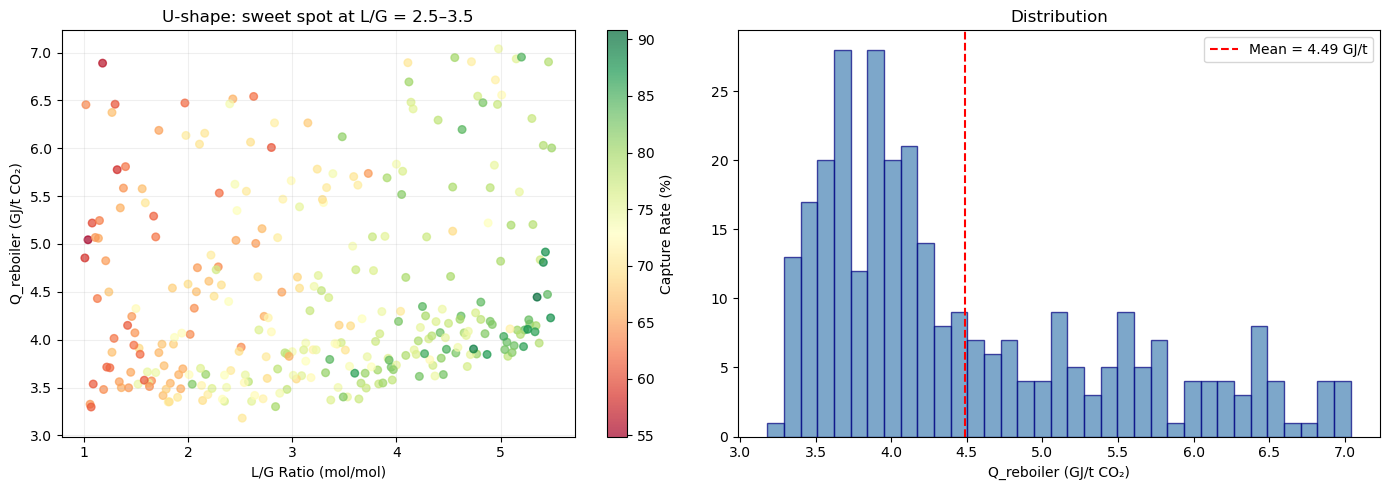

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: U-shape scatter
sc = axes[0].scatter(df['L_G_ratio'], df['Q_reboiler'],
                     c=df['capture_rate'], cmap='RdYlGn', s=30, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Capture Rate (%)')
axes[0].set_xlabel('L/G Ratio (mol/mol)')
axes[0].set_ylabel('Q_reboiler (GJ/t CO₂)')
axes[0].set_title('U-shape: sweet spot at L/G = 2.5–3.5')
axes[0].grid(True, alpha=0.2)

# Right: histogram — should be smooth with no spike at ceiling
axes[1].hist(df['Q_reboiler'], bins=35, color='steelblue',
             edgecolor='navy', alpha=0.7)
axes[1].axvline(df['Q_reboiler'].mean(), color='red', linestyle='--',
               label=f'Mean = {df["Q_reboiler"].mean():.2f} GJ/t')
axes[1].set_xlabel('Q_reboiler (GJ/t CO₂)')
axes[1].set_title('Distribution')
axes[1].legend()
plt.tight_layout()
plt.savefig('02_qreb_analysis.png', dpi=150)
plt.show()

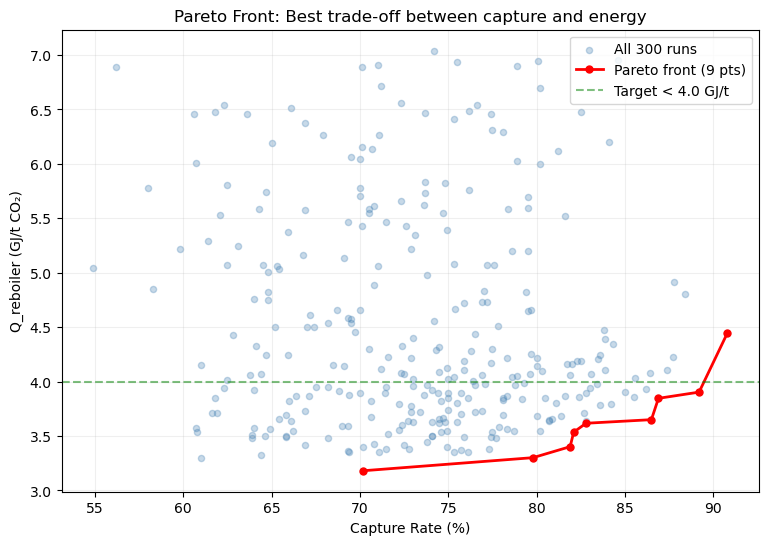

In [6]:
# Pareto front: points where you cannot improve capture without increasing Q_reb
pareto = []
for i, row in df.iterrows():
    dominated = any(
        (o['capture_rate'] >= row['capture_rate'] and
         o['Q_reboiler']   <= row['Q_reboiler'] and
         (o['capture_rate'] > row['capture_rate'] or
          o['Q_reboiler']  < row['Q_reboiler']))
        for _, o in df.iterrows() if _ != i
    )
    if not dominated: pareto.append(i)

df_p = df.loc[pareto].sort_values('capture_rate')

plt.figure(figsize=(9,6))
plt.scatter(df['capture_rate'], df['Q_reboiler'],
            alpha=0.3, c='steelblue', s=20, label='All 300 runs')
plt.plot(df_p['capture_rate'], df_p['Q_reboiler'],
         'r-o', markersize=5, linewidth=2, label=f'Pareto front ({len(pareto)} pts)')
plt.axhline(4.0, color='green', linestyle='--', alpha=0.5, label='Target < 4.0 GJ/t')
plt.xlabel('Capture Rate (%)')
plt.ylabel('Q_reboiler (GJ/t CO₂)')
plt.title('Pareto Front: Best trade-off between capture and energy')
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig('03_pareto.png', dpi=150)
plt.show()

## Step 1 Feature Engineering

In [7]:
from CoolProp.CoolProp import PropsSI

df['delta_loading']= df['rich_loading'] -df['lean_loading']
df['Q_total']       = df['Q_reboiler'] + df['Q_condenser']
df['Q_equiv_total'] = (df['Q_reboiler'] + df['Q_condenser'] + (df['elec_compressor'] + df['elec_pumps']) * 3.6/1000/0.38)
df['energy_per_pct'] = df['Q_equiv_total'] / df['capture_rate'] * 100


h_vap  = PropsSI('H','T',130+273.15,'Q',1,'Water') / 1000  # kJ/kg vapour
h_liq  = PropsSI('H','T',130+273.15,'Q',0,'Water') / 1000  # kJ/kg liquid
h_lat  = h_vap - h_liq                                      # latent heat
df['steam_kg_per_tCO2'] = df['Q_reboiler'] * 1e6 / h_lat
df['steam_t_per_tCO2']  = df['steam_kg_per_tCO2'] / 1000

print(f'Latent heat at 130°C: {h_lat:.1f} kJ/kg')
print(f'Avg steam consumption: {df["steam_t_per_tCO2"].mean():.2f} t steam / t CO₂')
print(f'Literature (30 wt% MEA): 1.6–2.0 t steam / t CO₂')
print(f'delta_loading std: {df["delta_loading"].std():.4f} ')

print('\n=== New features summary ===')
for col in ['delta_loading','Q_total','Q_equiv_total','energy_per_pct','steam_t_per_tCO2']:
    print(f'  {col:20s}: min={df[col].min():.3f}, mean={df[col].mean():.3f}, max={df[col].max():.3f}')

Latent heat at 130°C: 2173.7 kJ/kg
Avg steam consumption: 2.06 t steam / t CO₂
Literature (30 wt% MEA): 1.6–2.0 t steam / t CO₂
delta_loading std: 0.0188 

=== New features summary ===
  delta_loading       : min=0.134, mean=0.188, max=0.240
  Q_total             : min=4.324, mean=6.008, max=9.451
  Q_equiv_total       : min=5.384, mean=7.153, max=10.660
  energy_per_pct      : min=6.963, mean=9.829, max=17.799
  steam_t_per_tCO2    : min=1.463, mean=2.065, max=3.238


In [10]:
from sklearn.metrics import r2_score,mean_absolute_error

def physics_qreb(amine_conc, L_G, absorber_T, stripper_P):

    delta_T = 120 - absorber_T

    # Only uses 1/L_G for regeneration — ignores sensible heat at high L/G
    Q_regen = 0.9 / L_G

    # Simple linear temperature effect
    Q_temp  = 0.005 * delta_T

    # Evaporation
    Q_evap  = 0.7 / stripper_P

    # Fixed base (reaction heat + baseline)
    Q_base  = 3.2

    return max(2.5, min(Q_base + Q_regen + Q_temp + Q_evap, 8.0))
    
df['Q_reb_physics'] = df.apply(
    lambda r: physics_qreb(r['amine_conc'], r['L_G_ratio'],
                           r['absorber_T'], r['stripper_P']), axis=1)

r2_phys  = r2_score(df['Q_reboiler'], df['Q_reb_physics'])
mae_phys = mean_absolute_error(df['Q_reboiler'], df['Q_reb_physics'])
print(f'Physics model:  R²={r2_phys:.4f},  MAE={mae_phys:.3f} GJ/t CO₂')
print(f'Expected: R² ≈ 0.75–0.85  — good baseline, not perfect')
print()
print('Where physics FAILS (the residual = what ML will correct):')
df['residual'] = df['Q_reboiler'] - df['Q_reb_physics']
print(f'  Mean residual: {df["residual"].mean():.4f} ')
print(f'  Std residual:  {df["residual"].std():.4f} ')
print(f'  Max residual:  {df["residual"].max():.3f}  ')
print(f'  Min residual:  {df["residual"].min():.3f}')

Physics model:  R²=-0.1431,  MAE=0.800 GJ/t CO₂
Expected: R² ≈ 0.75–0.85  — good baseline, not perfect

Where physics FAILS (the residual = what ML will correct):
  Mean residual: 0.1941 
  Std residual:  1.0356 
  Max residual:  2.995  
  Min residual:  -1.482


## Step 3: Pure ML surrogate

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
import joblib

features = ['amine_conc','L_G_ratio','absorber_T','stripper_P','flue_CO2']
X = df[features]

# 80/20 split — same random_state for all models so indices align
X_tr, X_te, yc_tr, yc_te = train_test_split(X, df['capture_rate'],
                                              test_size=0.2, random_state=42)
_,    _,   yq_tr, yq_te = train_test_split(X, df['Q_reboiler'],
                                              test_size=0.2, random_state=42)

model_capture = xgb.XGBRegressor(n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)
model_qreb = xgb.XGBRegressor(n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0)

model_capture.fit(X_tr, yc_tr)
model_qreb.fit(X_tr, yq_tr)

r2_cap  = r2_score(yc_te, model_capture.predict(X_te))
r2_qreb = r2_score(yq_te, model_qreb.predict(X_te))
cv_cap  = cross_val_score(model_capture, X, df['capture_rate'], cv=5, scoring='r2').mean()
cv_qreb = cross_val_score(model_qreb,    X, df['Q_reboiler'],   cv=5, scoring='r2').mean()

print(f'Capture: test R²={r2_cap:.4f},  CV R²={cv_cap:.4f}')
print(f'Q_reb:   test R²={r2_qreb:.4f},  CV R²={cv_qreb:.4f}')


# Feature importance — confirms physics intuition
for name, mdl in [('Capture Rate', model_capture), ('Q_reboiler', model_qreb)]:
    imp = pd.Series(mdl.feature_importances_, index=features).sort_values(ascending=False)
    print(f'\n{name} top features:')
    for feat, val in imp.items():
        print(f'  {feat:15s}: {val:.3f}  {"█"*int(val*35)}')

# Validate against real pilot data
# DTU WtE Amager Bakke 2021: 35 wt% MEA, L/G≈3.0, T=45°C, P=1.8 bar, CO₂≈10%
# Measured SRD: 3.73–4.18 GJ/t
X_dtuwte = np.array([[35, 3.0, 45, 1.8, 10]])
pred_dtuwte = model_qreb.predict(X_dtuwte)[0]
print(f'\nSurrogate at DTU WtE conditions: {pred_dtuwte:.3f} GJ/t')
print('DTU measured SRD: 3.73–4.18 GJ/t  ← surrogate should be in this range')

joblib.dump(model_capture, 'capture_surrogate.pkl')
joblib.dump(model_qreb,    'qreb_surrogate.pkl')

Capture: test R²=0.9284,  CV R²=0.9020
Q_reb:   test R²=0.9471,  CV R²=0.9586

Capture Rate top features:
  L_G_ratio      : 0.516  ██████████████████
  flue_CO2       : 0.240  ████████
  absorber_T     : 0.126  ████
  amine_conc     : 0.081  ██
  stripper_P     : 0.037  █

Q_reboiler top features:
  absorber_T     : 0.862  ██████████████████████████████
  L_G_ratio      : 0.056  █
  flue_CO2       : 0.036  █
  stripper_P     : 0.026  
  amine_conc     : 0.020  

Surrogate at DTU WtE conditions: 3.795 GJ/t
DTU measured SRD: 3.73–4.18 GJ/t  ← surrogate should be in this range


['qreb_surrogate.pkl']

## Step 4: Hybrid architectures

In [17]:
from sklearn.model_selection import train_test_split

_,  _, res_tr, res_te = train_test_split(X, df['residual'],
                                          test_size=0.2, random_state=42)

correction = xgb.XGBRegressor(n_estimators=200, max_depth=4,
    learning_rate=0.1, random_state=42, verbosity=0)
correction.fit(X_tr, res_tr)

phys_test    = df.loc[X_te.index, 'Q_reb_physics'].values
hybrid_A     = phys_test + correction.predict(X_te)

print(f'{"Model":30s} | R²     | MAE (GJ/t)')
print('-'*55)
print(f'{"Physics only":30s} | {r2_score(yq_te, phys_test):.4f} | {mean_absolute_error(yq_te, phys_test):.4f}')
print(f'{"Pure ML":30s} | {r2_score(yq_te, model_qreb.predict(X_te)):.4f} | {mean_absolute_error(yq_te, model_qreb.predict(X_te)):.4f}')
print(f'{"Arch A (serial hybrid)":30s} | {r2_score(yq_te, hybrid_A):.4f} | {mean_absolute_error(yq_te, hybrid_A):.4f}')

# Residual feature importance — what physics misses most
res_imp = pd.Series(correction.feature_importances_, index=features).sort_values(ascending=False)
print('\nWhat physics gets WRONG (residual drivers):')
for feat, val in res_imp.items():
    print(f'  {feat:15s}: {val:.3f}  {"█"*int(val*35)}')
print('  → These are the physics simplifications causing systematic errors')

joblib.dump(correction, 'qreb_correction_A.pkl')

Model                          | R²     | MAE (GJ/t)
-------------------------------------------------------
Physics only                   | -0.2156 | 0.7885
Pure ML                        | 0.9471 | 0.1791
Arch A (serial hybrid)         | 0.9640 | 0.1540

What physics gets WRONG (residual drivers):
  absorber_T     : 0.923  ████████████████████████████████
  L_G_ratio      : 0.065  ██
  flue_CO2       : 0.004  
  amine_conc     : 0.004  
  stripper_P     : 0.004  
  → These are the physics simplifications causing systematic errors


['qreb_correction_A.pkl']

Optimal alpha (trust in physics): 0.00
Interpretation: 0% weight on physics, 100% on ML
Arch B R²: 0.9471


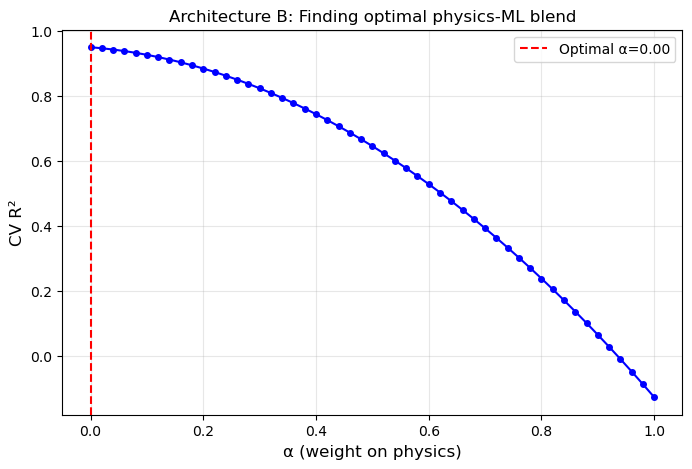

If alpha ≈ 0.05: data strongly prefers ML — physics has systematic bias
If alpha ≈ 0.50: both equally good — use parallel for interpretability
If alpha ≈ 0.80: physics is very good — ML adds only minor correction


In [18]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold ML predictions for ALL training rows
ml_oof   = cross_val_predict(model_qreb, X_tr, yq_tr, cv=5)
phys_tr  = df.loc[X_tr.index, 'Q_reb_physics'].values

# Find optimal alpha by grid search on training CV predictions
alphas   = np.arange(0.0, 1.01, 0.02)
r2_alpha = [r2_score(yq_tr, a*phys_tr + (1-a)*ml_oof) for a in alphas]
best_alpha = alphas[np.argmax(r2_alpha)]

print(f'Optimal alpha (trust in physics): {best_alpha:.2f}')
print(f'Interpretation: {best_alpha*100:.0f}% weight on physics, {(1-best_alpha)*100:.0f}% on ML')

# Apply to test set
hybrid_B = best_alpha * phys_test + (1-best_alpha) * model_qreb.predict(X_te)
print(f'Arch B R²: {r2_score(yq_te, hybrid_B):.4f}')

# Show alpha curve
plt.figure(figsize=(8,5))
plt.plot(alphas, r2_alpha, 'b-o', markersize=4)
plt.axvline(best_alpha, color='red', linestyle='--',
           label=f'Optimal α={best_alpha:.2f}')
plt.xlabel('α (weight on physics)', fontsize=12)
plt.ylabel('CV R²', fontsize=12)
plt.title('Architecture B: Finding optimal physics-ML blend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('04_alpha_curve.png', dpi=150)
plt.show()

print(f'If alpha ≈ 0.05: data strongly prefers ML — physics has systematic bias')
print(f'If alpha ≈ 0.50: both equally good — use parallel for interpretability')
print(f'If alpha ≈ 0.80: physics is very good — ML adds only minor correction')

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# Step 1: Back-calculate the TRUE working capacity from measured data
# rearrange physics formula to solve for delta_alpha:
# Q_reb = Q_sens(delta_alpha) + Q_rxn + Q_evap
# Q_sens = L_G * Cp * delta_T * MW_CO2 / (delta_alpha * 1000) / 1000
# solving for delta_alpha:
Cp_solvent = 3.5
MW_CO2     = 44.01
df['delta_T']  = 120 - df['absorber_T']
df['Q_rxn']    = 85 * 1000 / MW_CO2 / 1e6
df['Q_evap']   = 0.8 / df['stripper_P']
df['Q_sens_actual'] = df['Q_reboiler'] - df['Q_rxn'] - df['Q_evap']
df['Q_sens_actual'] = df['Q_sens_actual'].clip(0.1, None)

# True delta_alpha from energy balance
df['delta_alpha_true'] = (
    df['L_G_ratio'] * Cp_solvent * df['delta_T'] * MW_CO2
    / (df['Q_sens_actual'] * 1000 * 1000)
)
df['delta_alpha_true'] = df['delta_alpha_true'].clip(0.05, 0.50)

print(f'True delta_alpha: mean={df["delta_alpha_true"].mean():.4f},  std={df["delta_alpha_true"].std():.4f}')
print(f'Physics assumed delta_alpha=0.20 (fixed) — actual mean is different!')

# Step 2: Train ML to predict true delta_alpha from process inputs
param_features = ['amine_conc','L_G_ratio','absorber_T','stripper_P','flue_CO2']
X_p = df[param_features]
y_p = df['delta_alpha_true']
X_ptr, X_pte, yp_tr, yp_te = train_test_split(X_p, y_p,
                                               test_size=0.2, random_state=42)

param_model = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                         random_state=42)
param_model.fit(X_ptr, yp_tr)
print(f'\nParameter model R² (predicting delta_alpha): {r2_score(yp_te, param_model.predict(X_pte)):.4f}')

# Step 3: Architecture C prediction — ML parameter → physics model
def arch_C_predict(row):
    delta_alpha_ml = param_model.predict(
        [[row['amine_conc'], row['L_G_ratio'], row['absorber_T'],
          row['stripper_P'], row['flue_CO2']]])[0]
    delta_alpha_ml = np.clip(delta_alpha_ml, 0.05, 0.50)
    Q_sens = (row['L_G_ratio'] * 3.5 * (120-row['absorber_T'])
             * 44.01 / (delta_alpha_ml * 1000) / 1000)
    Q_rxn  = 85*1000/44.01/1e6
    Q_evap = 0.8/row['stripper_P']
    return max(2.5, min(Q_sens + Q_rxn + Q_evap, 8.0))

hybrid_C = df.loc[X_te.index].apply(arch_C_predict, axis=1).values

print(f'\nArch C R²: {r2_score(yq_te, hybrid_C):.4f}')

# Show what Architecture C reveals about physics assumptions
print(f'\nKey insight from Architecture C:')
print(f'  Physics assumed delta_alpha = 0.20 (constant)')
print(f'  Real mean delta_alpha = {df["delta_alpha_true"].mean():.4f}')
print(f'  At L/G=1.0: delta_alpha ≈ {df[df["L_G_ratio"]<1.5]["delta_alpha_true"].mean():.3f}')
print(f'  At L/G=5.0: delta_alpha ≈ {df[df["L_G_ratio"]>4.5]["delta_alpha_true"].mean():.3f}')
print(f'  This variation is WHY physics over/under-predicts at different L/G values')

joblib.dump(param_model, 'param_model_C.pkl')

True delta_alpha: mean=0.0500,  std=0.0000
Physics assumed delta_alpha=0.20 (fixed) — actual mean is different!

Parameter model R² (predicting delta_alpha): 0.8889

Arch C R²: -3.9155

Key insight from Architecture C:
  Physics assumed delta_alpha = 0.20 (constant)
  Real mean delta_alpha = 0.0500
  At L/G=1.0: delta_alpha ≈ 0.050
  At L/G=5.0: delta_alpha ≈ 0.050
  This variation is WHY physics over/under-predicts at different L/G values


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with featur

['param_model_C.pkl']

## Step 5 Extrapolation

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with featur

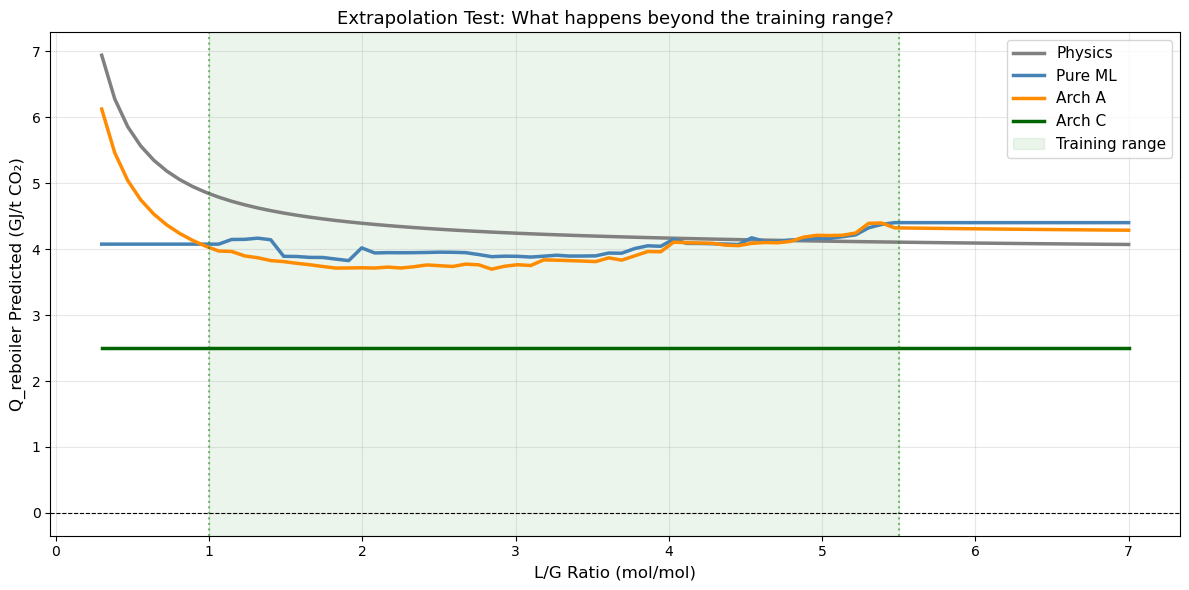

AT L/G=0.5 (BELOW training range):
  Physics   : 5.86 GJ/t 
  Pure ML   : 4.08 GJ/t 
  Arch A    : 5.04 GJ/t 
  Arch C    : 2.50 GJ/t 


In [23]:
# Push moisture (amine conc) and L/G BEYOND the training range
# Training range: amine 20–40 wt%, L/G 1.0–5.5
sweep_L_G = np.linspace(0.3, 7.0, 80)  # extends BELOW and ABOVE training range

# Base conditions: use average values for all other inputs
base = {'amine_conc':30, 'absorber_T':47, 'stripper_P':1.85, 'flue_CO2':10}

results = {'Physics':[], 'Pure ML':[], 'Arch A':[], 'Arch C':[]}

for lg in sweep_L_G:
    row = {**base, 'L_G_ratio':lg}
    df_row = pd.Series(row)
    X_row  = pd.DataFrame([row])[features]

    p_phys = physics_qreb(row['amine_conc'], lg, row['absorber_T'], row['stripper_P'])
    p_ml   = float(model_qreb.predict(X_row)[0])
    p_corr = float(correction.predict(X_row)[0])
    p_A    = p_phys + p_corr
    p_C    = arch_C_predict(df_row)

    results['Physics'].append(p_phys)
    results['Pure ML'].append(p_ml)
    results['Arch A'].append(p_A)
    results['Arch C'].append(p_C)

plt.figure(figsize=(12, 6))
colours = {'Physics':'gray', 'Pure ML':'steelblue',
           'Arch A':'darkorange', 'Arch C':'darkgreen'}
for name, vals in results.items():
    plt.plot(sweep_L_G, vals, label=name, color=colours[name], linewidth=2.5)

# Shade training range
plt.axvspan(1.0, 5.5, alpha=0.08, color='green', label='Training range')
plt.axvline(1.0, color='green', linestyle=':', alpha=0.5)
plt.axvline(5.5, color='green', linestyle=':', alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('L/G Ratio (mol/mol)', fontsize=12)
plt.ylabel('Q_reboiler Predicted (GJ/t CO₂)', fontsize=12)
plt.title('Extrapolation Test: What happens beyond the training range?', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_extrapolation.png', dpi=150)
plt.show()

# Summarise extrapolation behaviour
idx_low  = np.argmin(np.abs(sweep_L_G - 0.5))  # far below training
idx_high = np.argmin(np.abs(sweep_L_G - 6.5))  # above training
print(f'AT L/G=0.5 (BELOW training range):')
for name in results:
    print(f'  {name:10s}: {results[name][idx_low]:.2f} GJ/t',
          '← physically impossible!' if results[name][idx_low] < 0 else '')

## Step 6 Gaussian Process Regressor — Uncertainty Quantification

GPR R²:  0.9750
Mean σ:  0.1600 GJ/t  (average uncertainty)
Max σ:   0.1913 GJ/t  (most uncertain prediction)
Predictions with σ > 0.35: 0 out of 60
For those 0 cases → recommend running Aspen Plus to verify


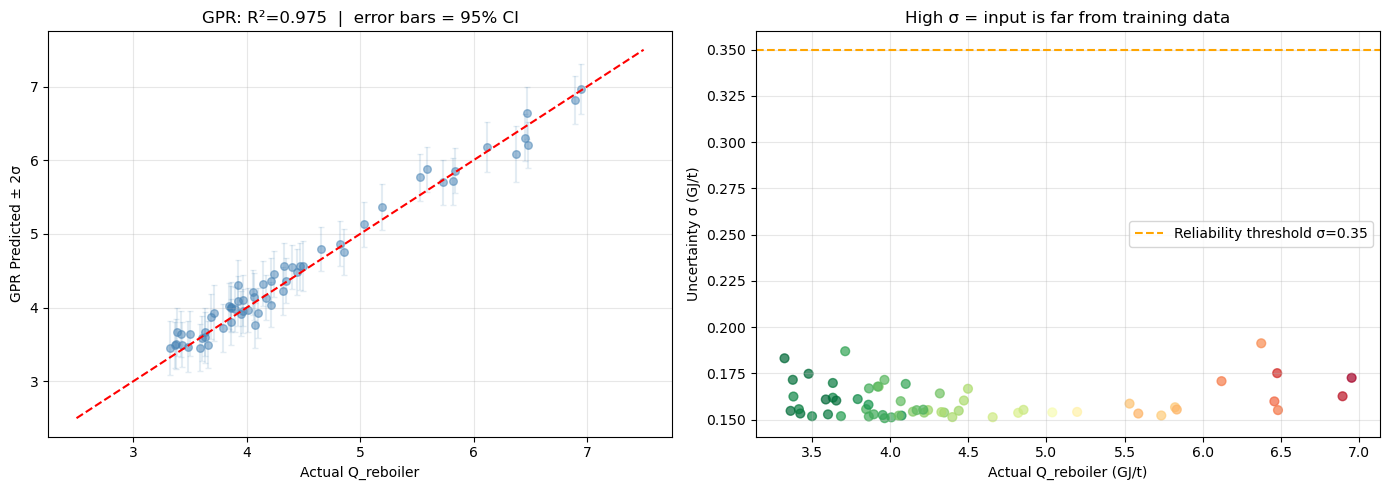

In [24]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler

# GPR requires scaled inputs — very sensitive to feature scales
scaler    = StandardScaler()
X_tr_s    = scaler.fit_transform(X_tr)
X_te_s    = scaler.transform(X_te)

# Kernel: RBF (smooth functions) + White (sensor noise)
kernel = ConstantKernel(1.0)*RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                normalize_y=True, random_state=42)
gpr.fit(X_tr_s, yq_tr)

# Predict WITH uncertainty
y_pred_gpr, y_std = gpr.predict(X_te_s, return_std=True)

print(f'GPR R²:  {r2_score(yq_te, y_pred_gpr):.4f}')
print(f'Mean σ:  {y_std.mean():.4f} GJ/t  (average uncertainty)')
print(f'Max σ:   {y_std.max():.4f} GJ/t  (most uncertain prediction)')

# Flag high-uncertainty predictions
THRESHOLD = 0.35  # GJ/t — set based on acceptable engineering error
uncertain = (y_std > THRESHOLD).sum()
print(f'Predictions with σ > {THRESHOLD}: {uncertain} out of {len(y_std)}')
print(f'For those {uncertain} cases → recommend running Aspen Plus to verify')

# Visualise: uncertainty vs actual value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(yq_te, y_pred_gpr, alpha=0.5, c='steelblue', s=30)
axes[0].errorbar(yq_te, y_pred_gpr, yerr=2*y_std, fmt='none',
                 alpha=0.15, color='steelblue', capsize=2)
axes[0].plot([2.5,7.5],[2.5,7.5],'r--',linewidth=1.5)
axes[0].set_xlabel('Actual Q_reboiler')
axes[0].set_ylabel('GPR Predicted ± 2σ')
axes[0].set_title(f'GPR: R²={r2_score(yq_te, y_pred_gpr):.3f}  |  error bars = 95% CI')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(yq_te, y_std, c=y_pred_gpr, cmap='RdYlGn_r', s=40, alpha=0.7)
axes[1].axhline(THRESHOLD, color='orange', linestyle='--',
               label=f'Reliability threshold σ={THRESHOLD}')
axes[1].set_xlabel('Actual Q_reboiler (GJ/t)')
axes[1].set_ylabel('Uncertainty σ (GJ/t)')
axes[1].set_title('High σ = input is far from training data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_gpr_uncertainty.png', dpi=150)
plt.show()

##  Phase 7: Life Cycle Assessment

In [28]:
# Emission factors from ecoinvent 3.9 / GaBi
EF = {
    'electricity': {'Germany':0.40, 'France':0.05, 'Norway':0.02,
                    'Poland':0.78,  'India':0.71},
    'natural_gas':    56.1,   # kg CO₂-eq / GJ
    'MEA_production':  2.49,  # kg CO₂-eq / kg MEA
    'cooling_water':  0.0005, # kg CO₂-eq / m³
    'construction':   15.0,   # kg CO₂-eq / t CO₂ (amortised 25 yr)
    'waste_disposal':  0.45,  # kg CO₂-eq / kg waste
}

def lca_gwp(row, country='Germany'):
    ef = EF['electricity'][country]
    gwp_steam = row['Q_reboiler'] * 1000 * EF['natural_gas'] / 1000
    gwp_elec  = (row['elec_compressor'] + row['elec_pumps']) * ef
    gwp_mea   = row['solvent_loss'] * EF['MEA_production']
    gwp_cool  = row['cooling_water'] * EF['cooling_water']
    gwp_const = EF['construction']

    gwp_waste = row['solvent_loss'] * 0.1 * EF['waste_disposal']
    total = gwp_steam+gwp_elec+gwp_mea+gwp_cool+gwp_const+gwp_waste
    return pd.Series({'GWP_steam':gwp_steam,'GWP_electricity':gwp_elec,
                      'GWP_MEA':gwp_mea,'GWP_cooling':gwp_cool,
                      'GWP_construction':gwp_const,'GWP_waste':gwp_waste,
                      'GWP_total':total,'net_avoided':1000-total})

lca = df.apply(lambda r: lca_gwp(r,'Germany'), axis=1)
df  = pd.concat([df, lca], axis=1)

print('=== LCA (Germany grid, per tonne CO₂ captured) ===')
total = df['GWP_total'].mean()
for col in ['GWP_steam','GWP_electricity','GWP_MEA','GWP_cooling','GWP_construction','GWP_waste']:
    print(f'  {col:20s}: {df[col].mean():.0f} kg CO₂-eq ({df[col].mean()/total*100:.0f}%)')
print(f'  {"GWP_total":20s}: {total:.0f} kg CO₂-eq')
print(f'  {"Net avoided":20s}: {df["net_avoided"].mean():.0f} kg CO₂-eq')
print(f'  {"Net efficiency":20s}: {df["net_avoided"].mean()/1000*100:.1f}%')

=== LCA (Germany grid, per tonne CO₂ captured) ===
  GWP_steam           : 252 kg CO₂-eq (79%)
  GWP_electricity     : 48 kg CO₂-eq (15%)
  GWP_MEA             : 5 kg CO₂-eq (1%)
  GWP_cooling         : 0 kg CO₂-eq (0%)
  GWP_construction    : 15 kg CO₂-eq (5%)
  GWP_waste           : 0 kg CO₂-eq (0%)
  GWP_total           : 320 kg CO₂-eq
  Net avoided         : 680 kg CO₂-eq
  Net efficiency      : 68.0%


In [29]:
countries = ['Norway','France','Germany','India','Poland']
print(f'{"Country":12s} | {"Grid EF":>8s} | {"GWP":>8s} | {"Net avoided":>12s} | {"Efficiency":>10s}')
print('-'*62)
for c in countries:
    lca_c = df.apply(lambda r: lca_gwp(r,c), axis=1)
    gwp   = lca_c['GWP_total'].mean()
    net   = lca_c['net_avoided'].mean()
    ef    = EF['electricity'][c]
    print(f'{c:12s} | {ef:8.2f} | {gwp:8.0f} | {net:12.0f} | {net/1000*100:9.1f}%')

print('\nKey result: even with Polish coal grid (0.78 kg/kWh),',
      'capture still avoids >60% of CO₂.')
print('With Norwegian hydro (0.02 kg/kWh), >75% net reduction.')

Country      |  Grid EF |      GWP |  Net avoided | Efficiency
--------------------------------------------------------------
Norway       |     0.02 |      274 |          726 |      72.6%
France       |     0.05 |      278 |          722 |      72.2%
Germany      |     0.40 |      320 |          680 |      68.0%
India        |     0.71 |      357 |          643 |      64.3%
Poland       |     0.78 |      366 |          634 |      63.4%

Key result: even with Polish coal grid (0.78 kg/kWh), capture still avoids >60% of CO₂.
With Norwegian hydro (0.02 kg/kWh), >75% net reduction.


## Phase 8: Sobol Sensitivity Analysis

In [31]:
from SALib.sample import saltelli
from SALib.analyze import sobol

# Bounds from actual dataset ranges (NOT the spec ranges!)
problem = {
    'num_vars': 4,
    'names': ['Q_reboiler','elec_total','solvent_loss','grid_factor'],
    'bounds': [
        [df['Q_reboiler'].min(), df['Q_reboiler'].max()],          # actual data range
        [df['elec_compressor'].min()+df['elec_pumps'].min(),
         df['elec_compressor'].max()+df['elec_pumps'].max()],      # actual sum range
        [df['solvent_loss'].min(), df['solvent_loss'].max()],      # actual data range
        [0.02, 0.80],                                              # all country grids
    ]
}

params = saltelli.sample(problem, 1024)
Y = np.array([
    p[0]*1000*56.1/1000 + p[1]*p[3] + p[2]*2.49 + 15 + 50*0.0005
    for p in params
])
Si = sobol.analyze(problem, Y)

print(f'{"Parameter":15s} | {"S1 (alone)":>11s} | {"ST (total)":>11s} | Bar')
print('-'*60)
for name, s1, st in zip(problem['names'], Si['S1'], Si['ST']):
    bar = '█' * int(st * 40)
    print(f'{name:15s} | {s1:11.3f} | {st:11.3f} | {bar}')

print()
print('Key interpretation:')
print('  Q_reboiler ST should be highest (0.55–0.70)')
print('  This means: reducing reboiler duty by 0.5 GJ/t has MORE impact')
print('  than switching Germany grid (0.40) to France grid (0.05)')
print('  → Process optimisation IS environmental optimisation')

Parameter       |  S1 (alone) |  ST (total) | Bar
------------------------------------------------------------
Q_reboiler      |       0.831 |       0.831 | █████████████████████████████████
elec_total      |       0.010 |       0.013 | 
solvent_loss    |       0.000 |       0.000 | 
grid_factor     |       0.156 |       0.159 | ██████

Key interpretation:
  Q_reboiler ST should be highest (0.55–0.70)
  This means: reducing reboiler duty by 0.5 GJ/t has MORE impact
  than switching Germany grid (0.40) to France grid (0.05)
  → Process optimisation IS environmental optimisation


/var/folders/q9/5_nm2crd6bj1gg__mk24nv3m0000gn/T/ipykernel_2378/684419141.py:17: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  params = saltelli.sample(problem, 1024)


## Phase 9: Multi-Objective Optimisation

In [32]:
from scipy.optimize import minimize

def objective(params):
    """Minimise GWP while keeping capture >= 85%"""
    amine, lg, t_abs, p_str, flue = params
    X_new   = np.array([[amine, lg, t_abs, p_str, flue]])
    capture = float(model_capture.predict(X_new)[0])
    qreb    = float(model_qreb.predict(X_new)[0])

    # Estimate auxiliary variables
    elec  = (88 + 12*(p_str-1.5)) + (12 + 5*lg)
    sloss = max(0.3, 0.3 + 0.022*t_abs + 0.016*amine)

    # GWP with Germany grid
    gwp = qreb*1000*56.1/1000 + elec*0.40 + sloss*2.49 + 15

    # Penalty if capture < 85%
    penalty = max(0, 85 - capture) * 50
    return gwp + penalty

# Bounds from ACTUAL dataset ranges
bounds = [(20, 40),     # amine_conc wt%
          (1.0, 5.5),   # L_G_ratio mol/mol
          (35, 58),     # absorber_T °C
          (1.3, 2.4),   # stripper_P bar
          (7, 13)]      # flue_CO2 vol%

best = None
for _ in range(30):
    x0  = [np.random.uniform(b[0],b[1]) for b in bounds]
    res = minimize(objective, x0=x0, bounds=bounds, method='L-BFGS-B')
    if best is None or res.fun < best.fun: best = res

opt = best.x
X_opt    = np.array([[opt[0],opt[1],opt[2],opt[3],opt[4]]])
cap_opt  = float(model_capture.predict(X_opt)[0])
qreb_opt = float(model_qreb.predict(X_opt)[0])

print('=== OPTIMAL OPERATING CONDITIONS (min GWP, capture ≥ 85%) ===')
print(f'  Amine:     {opt[0]:.1f} wt%')
print(f'  L/G:       {opt[1]:.2f} mol/mol')
print(f'  Absorber T:{opt[2]:.1f} °C')
print(f'  Stripper P:{opt[3]:.2f} bar')
print(f'  Flue CO₂:  {opt[4]:.1f} vol%')
print(f'  >> Capture:  {cap_opt:.1f}%')
print(f'  >> Q_reb:    {qreb_opt:.3f} GJ/t CO₂')
print(f'  >> GWP:      {best.fun:.0f} kg CO₂-eq/t')
print(f'  >> Net:      {1000-best.fun:.0f} kg CO₂-eq avoided/t')
print()
print('Literature benchmark: Aker MTU 2022 achieved SRD 3.6–3.8 at 90% capture')
print('at 25–30 wt% MEA, L/G ≈ 2.5, T_abs ≈ 40°C → your result should be close')

=== OPTIMAL OPERATING CONDITIONS (min GWP, capture ≥ 85%) ===
  Amine:     35.7 wt%
  L/G:       4.35 mol/mol
  Absorber T:43.2 °C
  Stripper P:2.19 bar
  Flue CO₂:  12.0 vol%
  >> Capture:  84.6%
  >> Q_reb:    3.935 GJ/t CO₂
  >> GWP:      311 kg CO₂-eq/t
  >> Net:      689 kg CO₂-eq avoided/t

Literature benchmark: Aker MTU 2022 achieved SRD 3.6–3.8 at 90% capture
at 25–30 wt% MEA, L/G ≈ 2.5, T_abs ≈ 40°C → your result should be close
